# Best vs Worst Random Ordering Trajectories (Hierarchical CI)

This notebook computes dataset-level trajectory curves for the **best** and **worst** random permutations, where:
- best/worst is chosen **within each (task, subset)** by permutation-level mean of the metric,
- then curves are aggregated with **hierarchical bootstrap** (subset -> task -> dataset).


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('/data/ddmg/mvseg-ordering')
for path in [REPO_ROOT, REPO_ROOT / 'UniverSeg', REPO_ROOT / 'MultiverSeg', REPO_ROOT / 'ScribblePrompt']:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_curve_2d
from experiments.analysis.planb_utils import load_planb_summaries


In [2]:
# -----------------------------
# Config
# -----------------------------
PROCEDURE = 'random_v2'
ABLATION = 'pretrained_baseline5'
POLICY_NAME = 'random'  # fixed for this analysis

METRICS = ['iterations_used', 'initial_dice', 'final_dice']
# Set to None to include all datasets found in the procedure/ablation.
DATASETS: list[str] | None = None
FAMILY_DISPLAY = {'T1mix': 'COBRE'}

N_BOOT = 2000
SEED = 23
N_COLS = 3

SAVE_FIG = False
FIG_DIR = REPO_ROOT / 'figures' / 'best_worst_permutation_trajectory_hierci'


In [3]:
def is_higher_better(metric_name: str) -> bool:
    lower_is_better = {'iterations_used'}
    return metric_name not in lower_is_better


def _build_task_curve_tables(
    selected_rows: pd.DataFrame,
    *,
    metric: str,
) -> dict[str, pd.DataFrame]:
    # One curve per subset: value vs image_index, then task table index=image_index, columns=subsets.
    subset_curves = (
        selected_rows
        .groupby(['task_id', 'subset_index', 'image_index'], as_index=False)[metric]
        .mean()
    )

    tables: dict[str, pd.DataFrame] = {}
    for task_id, grp in subset_curves.groupby('task_id'):
        table = grp.pivot(index='image_index', columns='subset_index', values=metric).sort_index()
        table.columns = [f'subset_{int(c)}' for c in table.columns]
        tables[str(task_id)] = table
    return tables


def build_best_worst_random_tables(
    df: pd.DataFrame,
    *,
    metric: str,
    policy_name: str,
) -> tuple[dict[str, pd.DataFrame], dict[str, pd.DataFrame], dict[str, int]]:
    required = {'task_id', 'subset_index', 'permutation_index', 'image_index', 'policy_name', metric}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')

    policy_df = df[df['policy_name'].astype(str) == str(policy_name)].copy()
    if policy_df.empty:
        raise ValueError(f'No rows found for policy_name={policy_name!r}')

    per_perm = (
        policy_df
        .groupby(['task_id', 'subset_index', 'permutation_index'], as_index=False)[metric]
        .mean()
        .rename(columns={metric: 'perm_score'})
    )

    higher = is_higher_better(metric)
    if higher:
        best_idx = per_perm.groupby(['task_id', 'subset_index'])['perm_score'].idxmax()
        worst_idx = per_perm.groupby(['task_id', 'subset_index'])['perm_score'].idxmin()
    else:
        best_idx = per_perm.groupby(['task_id', 'subset_index'])['perm_score'].idxmin()
        worst_idx = per_perm.groupby(['task_id', 'subset_index'])['perm_score'].idxmax()

    best_keys = per_perm.loc[best_idx, ['task_id', 'subset_index', 'permutation_index']].copy()
    worst_keys = per_perm.loc[worst_idx, ['task_id', 'subset_index', 'permutation_index']].copy()

    best_rows = policy_df.merge(
        best_keys,
        on=['task_id', 'subset_index', 'permutation_index'],
        how='inner',
        validate='many_to_one',
    )
    worst_rows = policy_df.merge(
        worst_keys,
        on=['task_id', 'subset_index', 'permutation_index'],
        how='inner',
        validate='many_to_one',
    )

    best_tables = _build_task_curve_tables(best_rows, metric=metric)
    worst_tables = _build_task_curve_tables(worst_rows, metric=metric)

    info = {
        'n_tasks_best': len(best_tables),
        'n_tasks_worst': len(worst_tables),
        'n_task_subset_pairs': int(per_perm[['task_id', 'subset_index']].drop_duplicates().shape[0]),
        'n_permutations_total': int(per_perm.shape[0]),
    }
    return best_tables, worst_tables, info


In [4]:
raw_df = load_planb_summaries(
    repo_root=REPO_ROOT,
    procedure=PROCEDURE,
    ablation=ABLATION,
    dataset=None,
)

raw_df = raw_df[raw_df['policy_name'].astype(str) == POLICY_NAME].copy()
if raw_df.empty:
    raise ValueError(f'No rows found for POLICY_NAME={POLICY_NAME!r}.')

available_datasets = sorted(raw_df['family'].dropna().astype(str).unique().tolist())
if DATASETS is None:
    datasets = available_datasets
else:
    requested = [str(x) for x in DATASETS]
    missing = [x for x in requested if x not in available_datasets]
    if missing:
        raise ValueError(f'Requested DATASETS not found: {missing}. Available: {available_datasets}')
    datasets = requested

raw_df = raw_df[raw_df['family'].astype(str).isin(datasets)].copy()

print(f'Loaded rows (policy={POLICY_NAME}): {len(raw_df):,}')
print(f'Datasets: {datasets}')
print(f'Ablation: {ABLATION}')


Loaded rows (policy=random): 1,650,000
Datasets: ['ACDC', 'BTCV', 'BUID', 'DRIVE', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']
Ablation: pretrained_baseline5


In [5]:
def compute_dataset_metric_curve(
    dataset_df: pd.DataFrame,
    *,
    metric: str,
    seed: int,
) -> tuple[pd.DataFrame, dict[str, int]]:
    best_tables, worst_tables, info = build_best_worst_random_tables(
        dataset_df,
        metric=metric,
        policy_name=POLICY_NAME,
    )

    best_boot = hierarchical_bootstrap_curve_2d(
        best_tables,
        n_boot=N_BOOT,
        seed=seed,
    )
    worst_boot = hierarchical_bootstrap_curve_2d(
        worst_tables,
        n_boot=N_BOOT,
        seed=seed + 10_000,
    )

    curve_df = pd.DataFrame({
        'context_size': best_boot['iterations'],
        'best_mean': best_boot['mean'].values,
        'best_ci_lo': best_boot['ci_lo'].values,
        'best_ci_hi': best_boot['ci_hi'].values,
        'worst_mean': worst_boot['mean'].values,
        'worst_ci_lo': worst_boot['ci_lo'].values,
        'worst_ci_hi': worst_boot['ci_hi'].values,
    })
    return curve_df, info


results: dict[str, dict[str, pd.DataFrame]] = {}
info_rows: list[dict[str, object]] = []
errors: list[str] = []

for metric_idx, metric in enumerate(METRICS):
    metric_results: dict[str, pd.DataFrame] = {}

    for ds_idx, dataset in enumerate(datasets):
        ds_df = raw_df[raw_df['family'].astype(str) == dataset].copy()

        if metric not in ds_df.columns:
            errors.append(f'{dataset} | {metric}: missing metric column')
            continue

        try:
            seed = SEED + metric_idx * 1000 + ds_idx
            curve_df, info = compute_dataset_metric_curve(ds_df, metric=metric, seed=seed)
            metric_results[dataset] = curve_df
            info_rows.append(
                {
                    'metric': metric,
                    'family': dataset,
                    **info,
                }
            )
        except Exception as exc:
            errors.append(f'{dataset} | {metric}: {exc}')

    results[metric] = metric_results

info_df = pd.DataFrame(info_rows)
print('Computed curves for metrics:', {k: len(v) for k, v in results.items()})
if errors:
    print()
    print('Errors:')
    for e in errors:
        print(' -', e)

info_df.head()


Computed curves for metrics: {'iterations_used': 11, 'initial_dice': 11, 'final_dice': 11}


,metric,family,n_tasks_best,n_tasks_worst,n_task_subset_pairs,n_permutations_total
0,iterations_used,ACDC,6,6,60,6000
1,iterations_used,BTCV,20,20,200,20000
2,iterations_used,BUID,4,4,40,4000
3,iterations_used,DRIVE,2,2,20,2000
4,iterations_used,HipXRay,4,4,40,4000


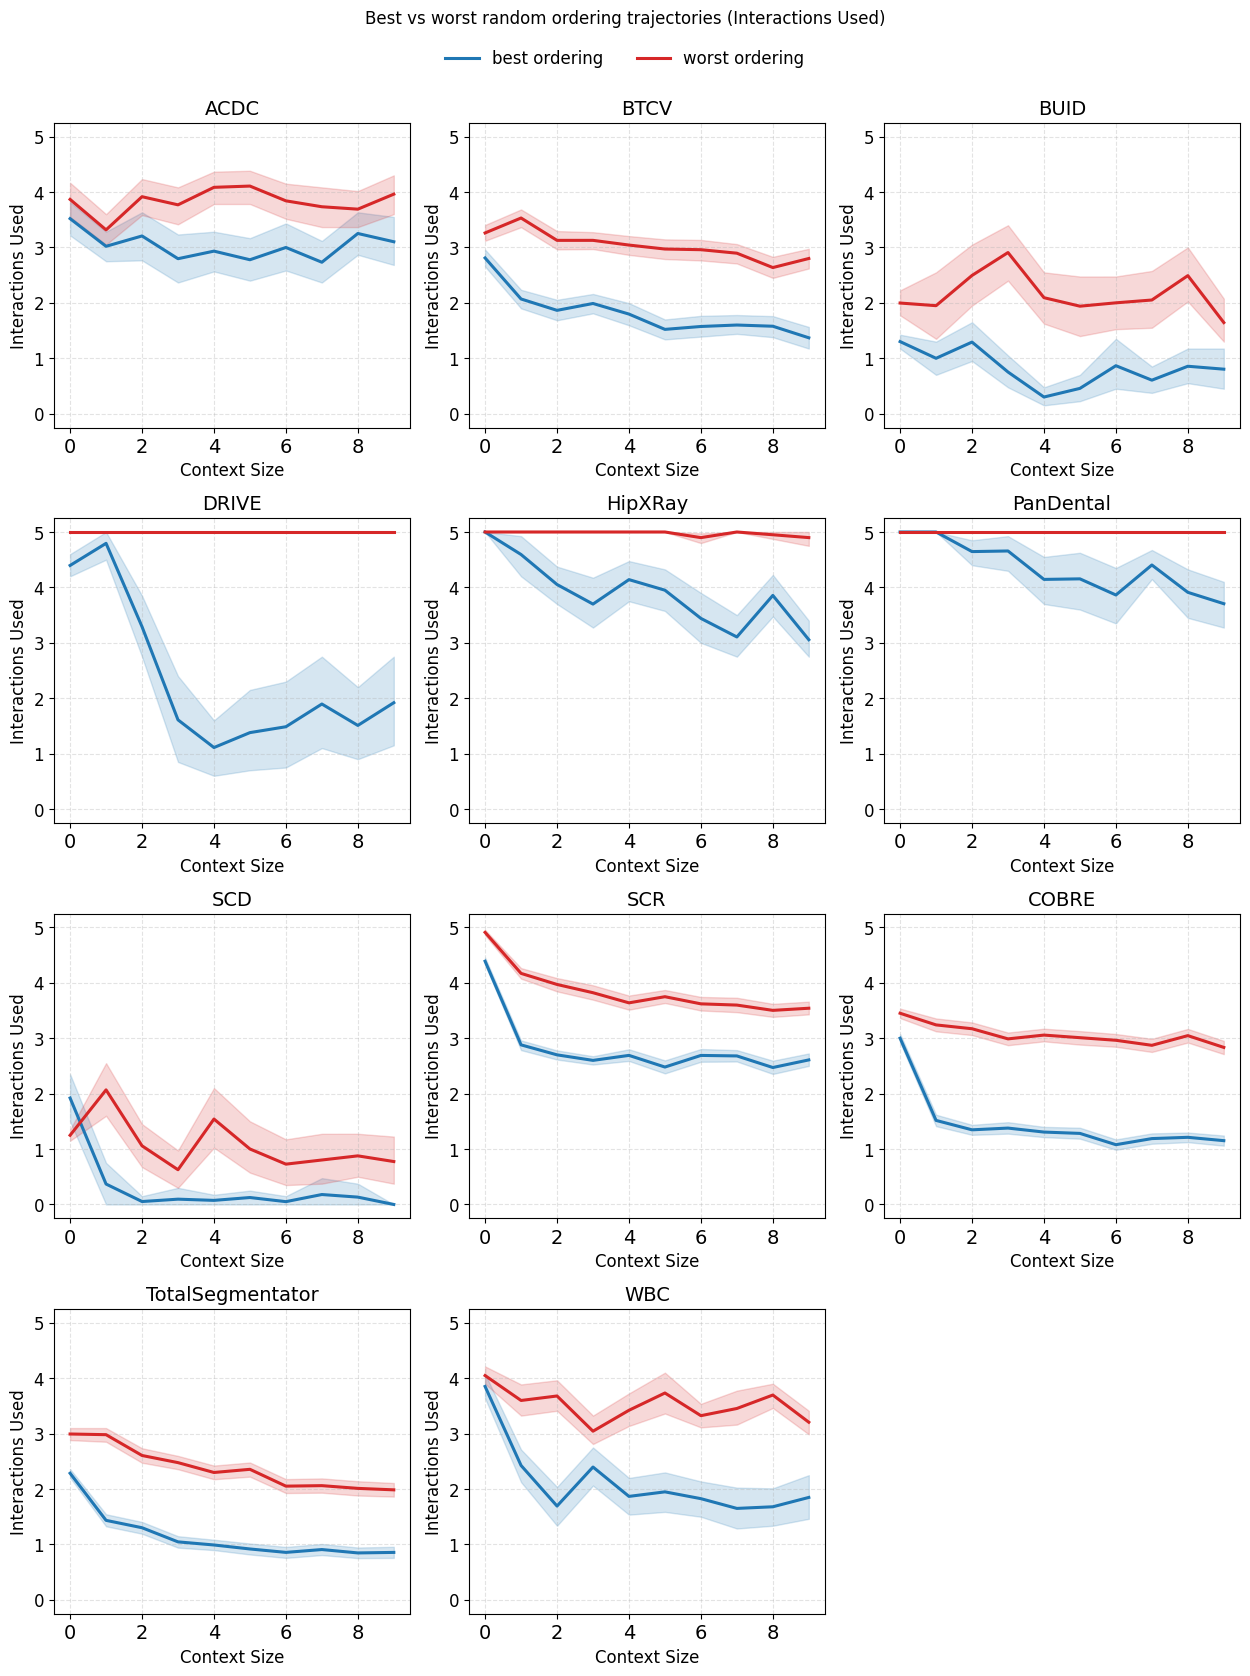

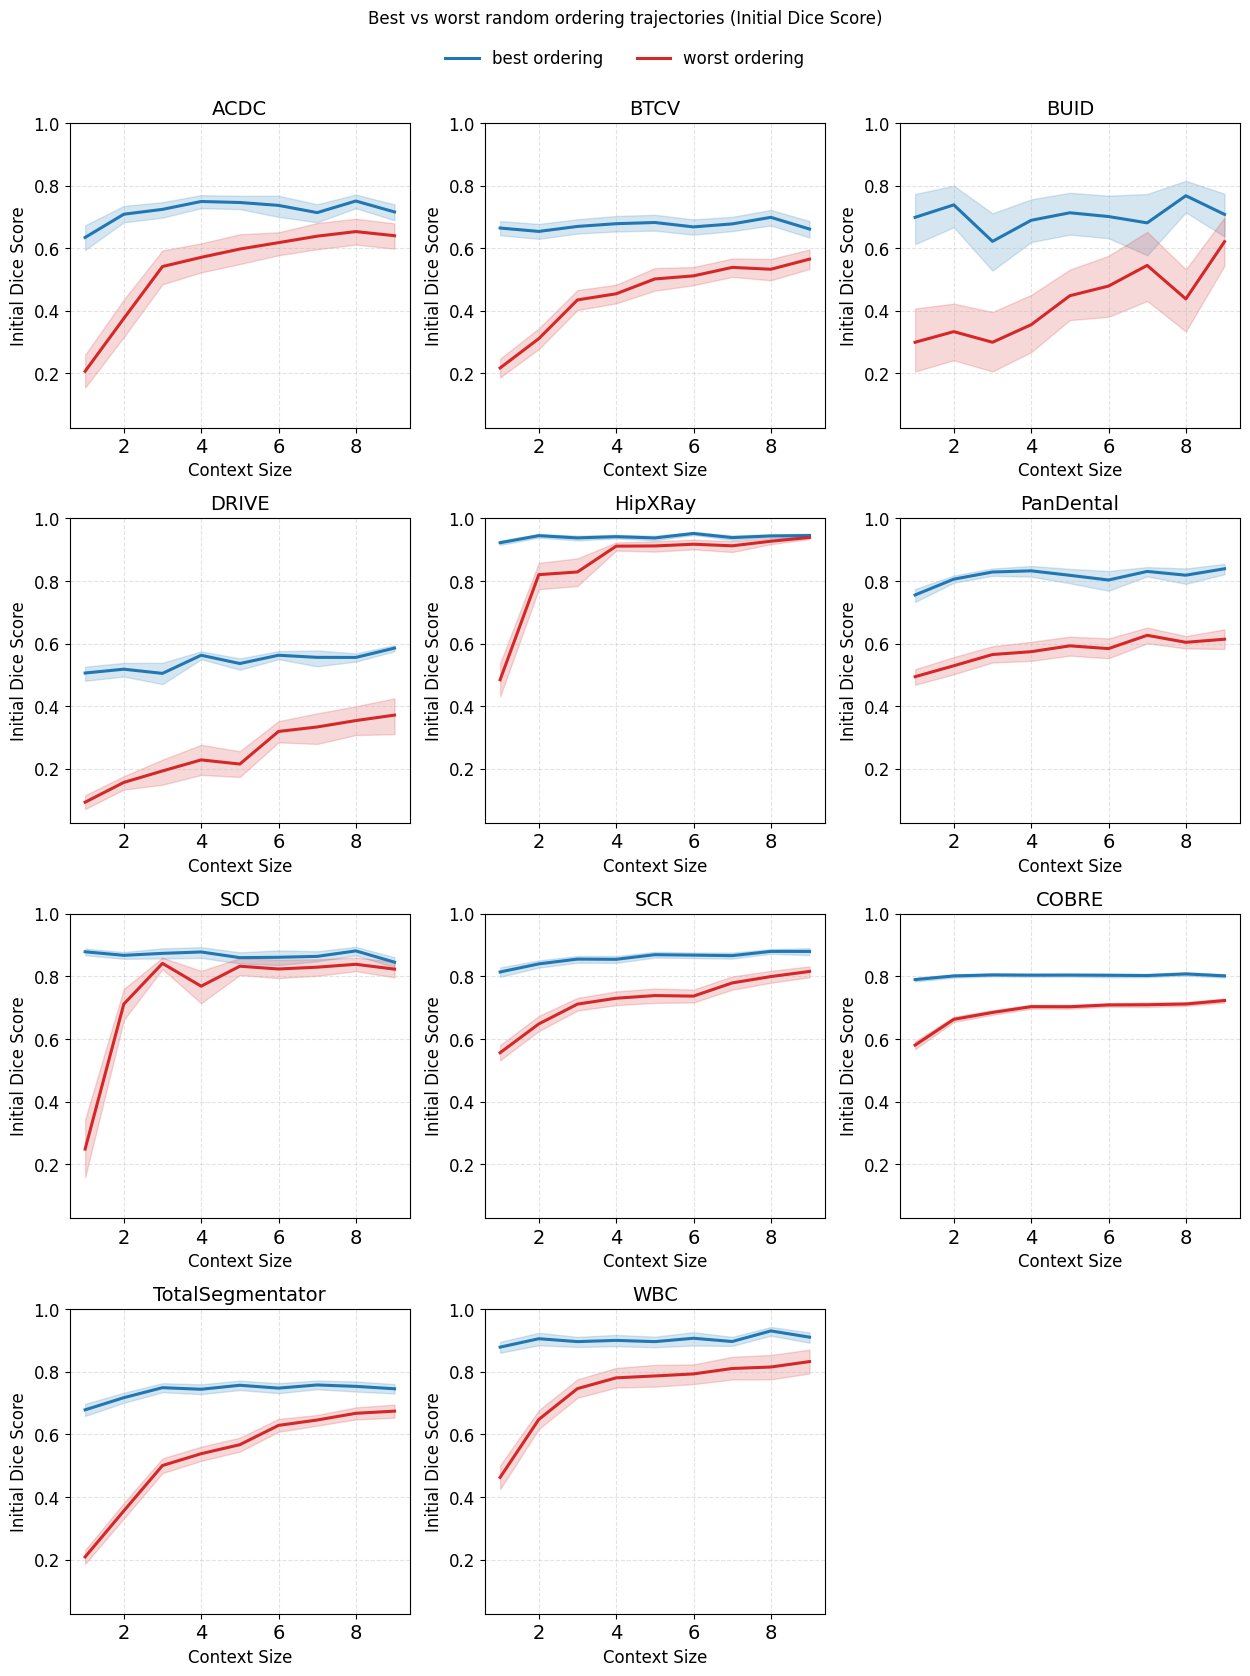

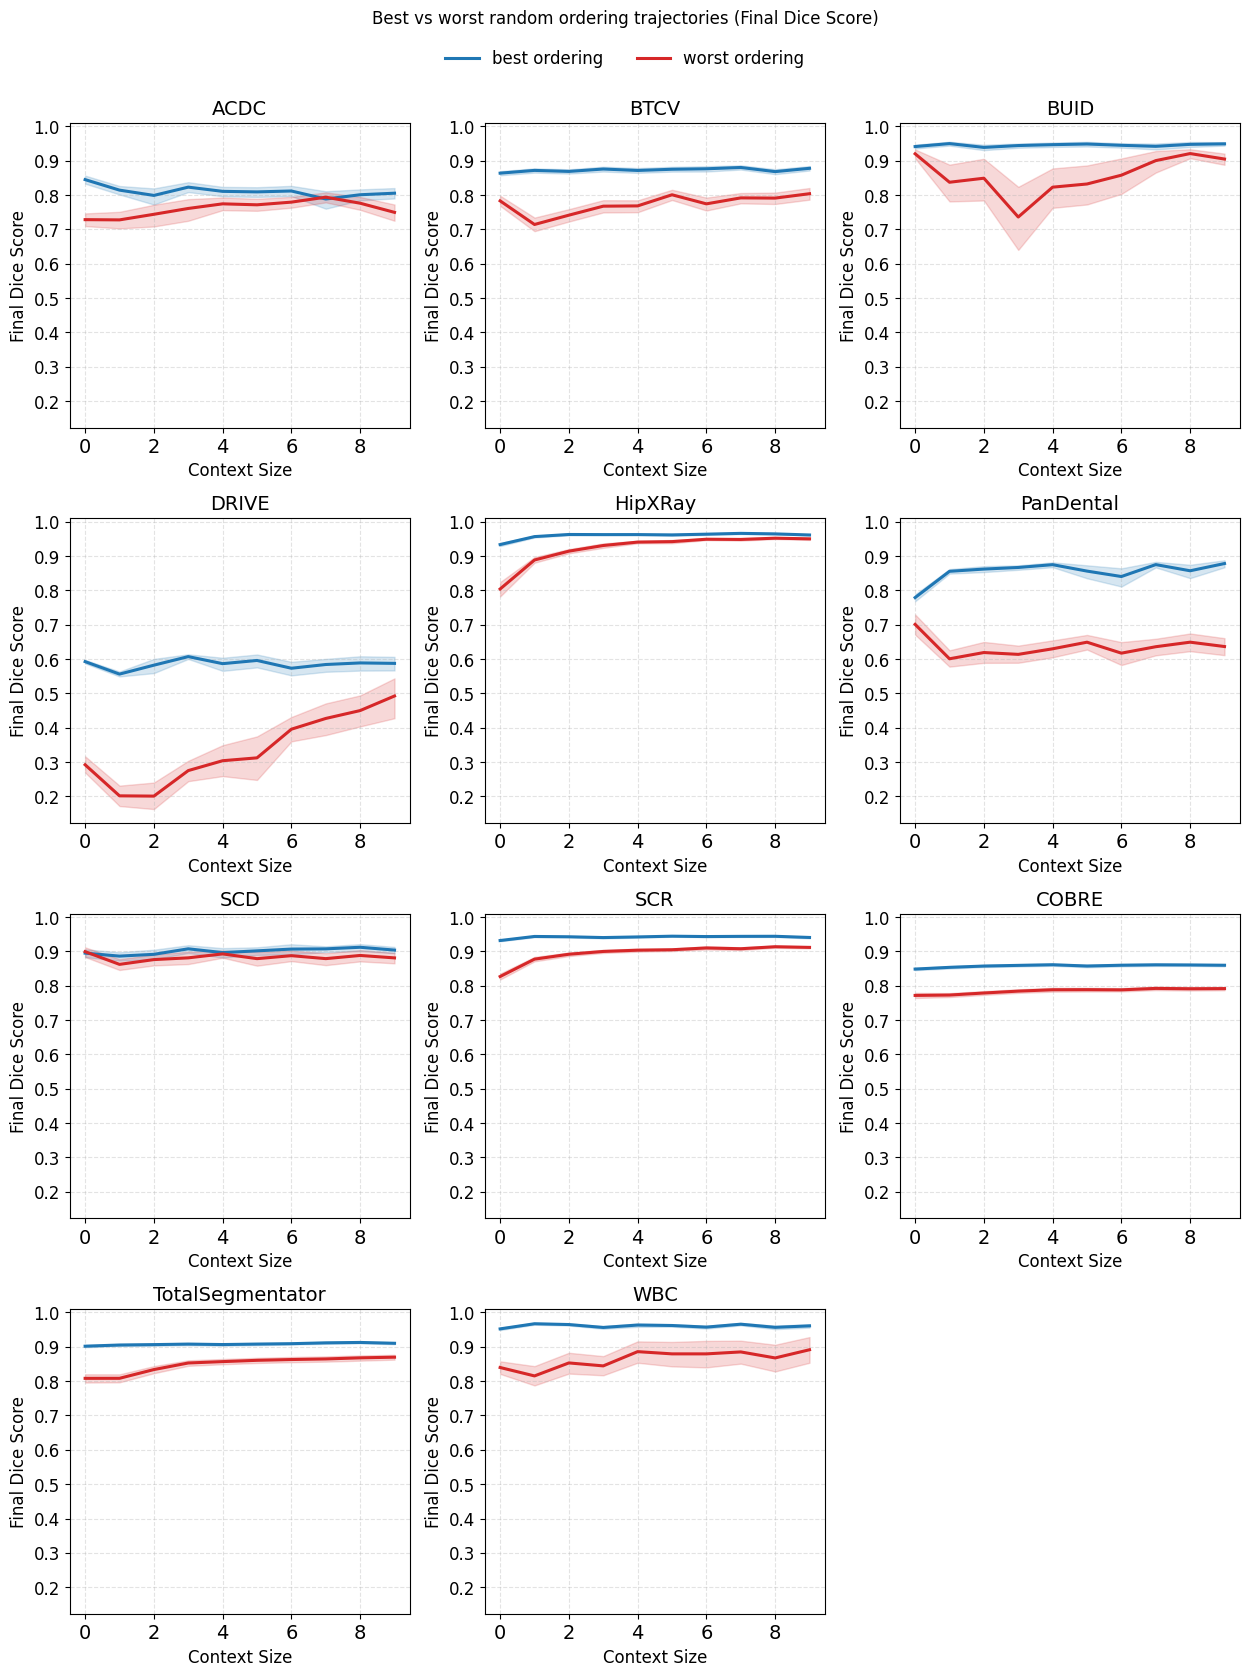

In [6]:
from experiments.analysis.notebook_plot_style import (
    FONT_SIZE_SUPTITLE,
    FONT_SIZE_PANEL_TITLE,
    FONT_SIZE_XLABEL,
    FONT_SIZE_YLABEL,
    FONT_SIZE_XTICKS,
    FONT_SIZE_YTICKS,
    FONT_SIZE_LEGEND,
)

METRIC_DISPLAY = {
    'iterations_used': 'Interactions Used',
    'initial_dice': 'Initial Dice Score',
    'final_dice': 'Final Dice Score',
}


for metric in METRICS:
    metric_results = results.get(metric, {})
    if not metric_results:
        print(f'[skip] No curves for metric={metric}')
        continue

    metric_label = METRIC_DISPLAY.get(metric, metric.replace('_', ' '))

    families = sorted(metric_results.keys())
    n_families = len(families)
    n_cols = int(max(1, N_COLS))
    n_rows = 4

    fig, axes = plt.subplots(
        n_rows,
        3,
        figsize=(4.2 * n_cols, 4.2 * n_rows),
        squeeze=False,
         sharey=True,
    )
    axes_flat = axes.ravel()

    for i, family in enumerate(families):
        ax = axes_flat[i]
        curve_df = metric_results[family]
        if metric == 'initial_dice':
            curve_df = curve_df[curve_df['context_size'] > 0].reset_index(drop=True)
        x = curve_df['context_size'].to_numpy(dtype=float)
        ax.tick_params(axis='y', labelleft=True, labelsize=FONT_SIZE_YTICKS)
        ax.tick_params(axis='x', labelsize=FONT_SIZE_XTICKS + 2)

        ax.plot(x, curve_df['best_mean'], color='#1f77b4', linewidth=2.2, label='best ordering')
        ax.fill_between(x, curve_df['best_ci_lo'], curve_df['best_ci_hi'], color='#1f77b4', alpha=0.18)

        ax.plot(x, curve_df['worst_mean'], color='#d62728', linewidth=2.2, label='worst ordering')
        ax.fill_between(x, curve_df['worst_ci_lo'], curve_df['worst_ci_hi'], color='#d62728', alpha=0.18)

        task_count = '?'
        if not info_df.empty:
            match = info_df[(info_df['metric'] == metric) & (info_df['family'] == family)]
            if not match.empty:
                task_count = int(match['n_tasks_best'].iloc[0])

        ax.set_title(FAMILY_DISPLAY.get(family, family), fontsize=FONT_SIZE_PANEL_TITLE)
        ax.set_xlabel('Context Size', fontsize=FONT_SIZE_XLABEL)
        ax.set_ylabel(metric_label, fontsize=FONT_SIZE_YLABEL)
        ax.grid(True, linestyle='--', alpha=0.35)

    for j in range(n_families, len(axes_flat)):
        axes_flat[j].axis('off')

    handles, labels = axes_flat[0].get_legend_handles_labels()


    fig.suptitle(f'Best vs worst random ordering trajectories ({metric_label})', fontsize=FONT_SIZE_SUPTITLE, y=0.995)

    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.98),  # below title
        ncol=2,
        frameon=False,
        fontsize=FONT_SIZE_LEGEND,
    )

    fig.tight_layout(rect=(0, 0, 1, 0.97))  # reserve top 7%


    if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        out_path = FIG_DIR / f'{PROCEDURE}_{ABLATION}_{metric}_best_worst_random_dataset_grid.png'
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f'saved: {out_path}')

    plt.show()


In [7]:
# Optional: dataset/metric coverage table.
info_df.sort_values(['metric', 'family']).reset_index(drop=True)


,metric,family,n_tasks_best,n_tasks_worst,n_task_subset_pairs,n_permutations_total
0,final_dice,ACDC,6,6,60,6000
1,final_dice,BTCV,20,20,200,20000
2,final_dice,BUID,4,4,40,4000
3,final_dice,DRIVE,2,2,20,2000
4,final_dice,HipXRay,4,4,40,4000
5,final_dice,PanDental,4,4,40,4000
6,final_dice,SCD,4,4,40,4000
7,final_dice,SCR,20,20,200,20000
8,final_dice,T1mix,46,46,460,46000
9,final_dice,TotalSegmentator,47,47,470,47000


In [8]:
# --- Best vs Worst Gap in Interaction Cost at Selected Positions ---
# Computes worst - best interaction cost gap at specified positions with hierarchical bootstrap CI.
# Uses subset -> task -> dataset bootstrap; global CI is mean of dataset bootstraps by index.

GAP_METRIC = 'iterations_used'
GAP_POSITIONS = [1, 5, 9]  # image positions (context size) to report
GAP_N_BOOT = N_BOOT
GAP_SEED = SEED + 4242

from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_curve_2d


def _gap_boot_for_dataset(ds_df: pd.DataFrame, *, metric: str, seed: int) -> dict[int, dict[str, float | int]]:
    # Rebuild best/worst tables for the dataset and compute bootstrapped curves.
    best_tables, worst_tables, info = build_best_worst_random_tables(
        ds_df,
        metric=metric,
        policy_name=POLICY_NAME,
    )
    best_boot = hierarchical_bootstrap_curve_2d(best_tables, n_boot=GAP_N_BOOT, seed=seed)
    worst_boot = hierarchical_bootstrap_curve_2d(worst_tables, n_boot=GAP_N_BOOT, seed=seed + 10000)

    iterations = best_boot['iterations']
    # boot_curves: shape (n_boot, n_steps)
    best_arr = best_boot['boot_curves']
    worst_arr = worst_boot['boot_curves']

    # Worst - best (positive means worse ordering requires more interactions)
    gap_arr = worst_arr - best_arr

    out: dict[int, dict[str, float | int]] = {}
    for pos in GAP_POSITIONS:
        if pos not in iterations:
            continue
        idx = iterations.index(pos)
        vals = gap_arr[:, idx]
        out[pos] = {
            'mean': float(vals.mean()),
            'ci_lo': float(np.quantile(vals, 0.025)),
            'ci_hi': float(np.quantile(vals, 0.975)),
            'n_boot': int(len(vals)),
        }
    return out


# Per-dataset gap CIs
rows = []
metric = GAP_METRIC
for ds_idx, dataset in enumerate(datasets):
    ds_df = raw_df[raw_df['family'].astype(str) == dataset].copy()
    if metric not in ds_df.columns:
        continue
    try:
        gap_stats = _gap_boot_for_dataset(ds_df, metric=metric, seed=GAP_SEED + ds_idx)
        for pos, stats in gap_stats.items():
            rows.append({
                'family': dataset,
                'position': pos,
                'gap_mean': stats['mean'],
                'gap_ci_lo': stats['ci_lo'],
                'gap_ci_hi': stats['ci_hi'],
                'n_boot': stats['n_boot'],
            })
    except Exception as exc:
        print(f'[gap-skip] {dataset}: {exc}')

per_dataset_gap = pd.DataFrame(rows).sort_values(['family', 'position'])
print('Per-dataset worst-best gap (interactions used):')
if per_dataset_gap.empty:
    print('  [none]')
else:
    display(per_dataset_gap)


# Global gap: average dataset bootstraps index-wise
# Recompute bootstraps per dataset to avoid caching; keep them aligned by bootstrap index.

boot_by_dataset: dict[str, dict[int, np.ndarray]] = {}
for ds_idx, dataset in enumerate(datasets):
    ds_df = raw_df[raw_df['family'].astype(str) == dataset].copy()
    if metric not in ds_df.columns:
        continue
    try:
        best_tables, worst_tables, _ = build_best_worst_random_tables(
            ds_df,
            metric=metric,
            policy_name=POLICY_NAME,
        )
        best_boot = hierarchical_bootstrap_curve_2d(best_tables, n_boot=GAP_N_BOOT, seed=GAP_SEED + ds_idx)
        worst_boot = hierarchical_bootstrap_curve_2d(worst_tables, n_boot=GAP_N_BOOT, seed=GAP_SEED + ds_idx + 10000)

        iterations = best_boot['iterations']
        gap_arr = worst_boot['boot_curves'] - best_boot['boot_curves']
        boot_by_dataset[dataset] = {
            pos: gap_arr[:, iterations.index(pos)]
            for pos in GAP_POSITIONS
            if pos in iterations
        }
    except Exception as exc:
        print(f'[global-gap-skip] {dataset}: {exc}')

# Aggregate global by position
rows = []
for pos in GAP_POSITIONS:
    series_list = [boot_by_dataset[d][pos] for d in boot_by_dataset if pos in boot_by_dataset[d]]
    if not series_list:
        continue
    # average dataset bootstraps index-wise
    min_len = min(len(s) for s in series_list)
    stacked = np.vstack([s[:min_len] for s in series_list])
    global_boot = stacked.mean(axis=0)
    rows.append({
        'position': pos,
        'gap_mean': float(global_boot.mean()),
        'gap_ci_lo': float(np.quantile(global_boot, 0.025)),
        'gap_ci_hi': float(np.quantile(global_boot, 0.975)),
        'n_boot': int(len(global_boot)),
        'n_datasets': int(stacked.shape[0]),
    })

global_gap = pd.DataFrame(rows).sort_values('position')
print('Global worst-best gap (interactions used):')
if global_gap.empty:
    print('  [none]')
else:
    display(global_gap) 


Per-dataset worst-best gap (interactions used):


,family,position,gap_mean,gap_ci_lo,gap_ci_hi,n_boot
0,ACDC,1,0.292892,-0.100000,0.666667,2000
1,ACDC,5,1.316700,0.833333,1.783333,2000
2,ACDC,9,0.859258,0.283333,1.450000,2000
3,BTCV,1,1.456972,1.225000,1.690000,2000
4,BTCV,5,1.456367,1.205000,1.715000,2000
5,BTCV,9,1.432242,1.184875,1.705000,2000
6,BUID,1,0.941025,0.324375,1.575000,2000
7,BUID,5,1.493862,0.950000,2.075000,2000
8,BUID,9,0.843938,0.350000,1.375000,2000
9,DRIVE,1,0.198050,0.000000,0.500000,2000


Global worst-best gap (interactions used):


,position,gap_mean,gap_ci_lo,gap_ci_hi,n_boot,n_datasets
0,1,0.974659,0.871981,1.080706,2000,11
1,5,1.532713,1.403574,1.669461,2000,11
2,9,1.387888,1.256067,1.515979,2000,11
